In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

D:\Promotion\neurolib\GUI\gui\data\10100
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(i, found_solution, exc, inh, already_tried):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    min_dist = np.sqrt((exc[i] - exc[found_solution[0]])**2 + (inh[i] - inh[found_solution[0]])**2)
    min_i = 0
    
    if i == 0:
        min_dist = np.sqrt((exc[i] - exc[1])**2 + (inh[i] - inh[1])**2)
        min_i = 1
        
    if len(found_solution) == len(already_tried):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution[1:]:
        if i_ not in already_tried:
            if i_ != i and i_ != min_i:
                dist_ = np.sqrt((exc[i] - exc[i_])**2 + (inh[i] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
    return min_i

152


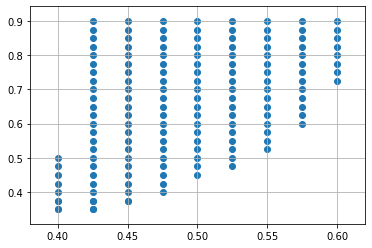

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 17
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [151]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.4064792389245
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.4064792389245
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.88683979421
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.88683979421
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  52 0.5500000000000003 0.5750000000000003
set cost params:  1.0 0.0 0.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30191.234275043666
Gradient descend method:  None
RUN  0 , total integrated cost =  30191.234275043666
Improved over  0  iterations

In [152]:
i_range_ = []

for i in i_range:
    print(i, type(bestControl_init[i]))
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

0 <class 'NoneType'>
26 <class 'NoneType'>
52 <class 'NoneType'>
78 <class 'NoneType'>
104 <class 'NoneType'>
130 <class 'NoneType'>
[  0  26  52  78 104 130]


In [153]:
factor_iteration = 20

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.4064792389245
Gradient descend method:  None
RUN  1 , total integrated cost =  182.34125558811405
RUN  2 , total integrated cost =  6.524764621175612
RUN  3 , total integrated cost =  0.27475912632007515
RUN  4 , total integrated cost =  0.19999061864143272
RUN  5 , total integrated cost =  0.1948742269604943
RUN  6 , total integrated cost =  0.19329814894642555
RUN  7 , total integrated cost =  0.19138120533692793
RUN  8 , total integrated cost =  0.19040478491455934
RUN  9 , total integrated cost =  0.18180164761955137
RUN  10 , total integrated cost =  0.18170040563764867
RUN  11 , total integrated cost =  0.1816914697591792
RUN  12 , total integrated cost =  0.17841212827028807
RUN  13 , total integrated cost =  0.17792565586685816
RUN  14 , total integrated cost =  0.177

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  0.1771204429291928
RUN  20 , total integrated cost =  0.1771204429291928
Improved over  20  iterations in  1.3792396999997436  seconds by  99.99699918256135  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6059595825059272
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.257523918436533
Problem in initial value trasfer:  Vmean_exc -56.62762078834495 -56.627620763394226
weight =  333242.5315579479
set cost params:  1.0 0.0 333242.5315579479
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5892.65972369673
Gradient descend method:  None
RUN  1 , total integrated cost =  5481.0687853162
RUN  2 , total integrated cost =  5477.154912941189
RUN  3 , total integrated cost =  5260.0631833975585
RUN  4 , total integrated cost =  5259.8517098404645
RUN  5 , total integrated cost =  5259.846335636321
RUN  6 , total integrated cost =  5259.845888232011
RUN  7 , total integ

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5259.845847103767
Control only changes marginally.
RUN  19 , total integrated cost =  5259.845847103767
Improved over  19  iterations in  1.8580308999989938  seconds by  10.739019496546987  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6072132186173338
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.24323082286171
Problem in initial value trasfer:  Vmean_exc -56.62668656035363 -56.62669372969238
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.88683979421
Gradient descend method:  None
RUN  1 , total integrated cost =  6.375912978796904
RUN  2 , total integrated cost =  3.9715032154423677
RUN  3 , total integrated cost =  0.49172121897744153
RUN  4 , total integrated cost =  0.4644018783461643
RUN  5 , total integrated cost =  0.4492730707759

...

RUN  11 , total integrated cost =  22967.054881138807
RUN  12 , total integrated cost =  22967.054881138807
Control only changes marginally.
RUN  12 , total integrated cost =  22967.054881138807
Improved over  12  iterations in  1.1834167999986676  seconds by  5.942306573324956  percent.
Problem in initial value trasfer:  sigmae_f 1.5033533472016083 1.503352218965589
Problem in initial value trasfer:  tau_exc 21.405157768934426 21.40516423434956
Problem in initial value trasfer:  Vmean_exc -56.701913753755704 -56.701914062956604
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.770160604903
Gradient descend method:  None
RUN  1 , total integrated cost =  6120.770160604903
Control only changes marginally.
RUN  1 , total integrated cost =  6120.770160604903
Improved over  1  iterations in  0.12436779999916325  seconds by  0.

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  1.0316913600691617
RUN  19 , total integrated cost =  1.0309486895831868
RUN  20 , total integrated cost =  0.9915447399168914
RUN  20 , total integrated cost =  0.9915447399168914
Improved over  20  iterations in  1.4094083000018145  seconds by  99.9931843128385  percent.
Problem in initial value trasfer:  Vmean_exc -56.67729477129714 -56.67729584991541
weight =  146720.34914509926
set cost params:  1.0 0.0 146720.34914509926
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14319.018877999219
Gradient descend method:  None
RUN  1 , total integrated cost =  13233.64183493485
RUN  2 , total integrated cost =  13193.713718451694
RUN  3 , total integrated cost =  13146.100925826391
RUN  4 , total integrated cost =  13142.33542927035
RUN  5 , total integrated cost =  13125.671629527333
RUN  6 , total integrated cost =  13095.705996962339
RUN  7 , total integrated cost =  13092.640812078713
RUN  8 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  44 , total integrated cost =  12942.554120794486
Improved over  44  iterations in  3.8521221999981208  seconds by  9.612842674016122  percent.
Problem in initial value trasfer:  Vmean_exc -56.676859898407244 -56.67687063457928


[array([[91.53878128,  0.        ]]), array([[0.00000000e+00, 0.00000000e+00, 1.09391520e-02, 0.00000000e+00,
        9.68839573e-36, 0.00000000e+00]]), array([[0.00000000e+00, 0.00000000e+00, 1.47913164e-01, 0.00000000e+00,
        4.40190771e-18, 0.00000000e+00]])]


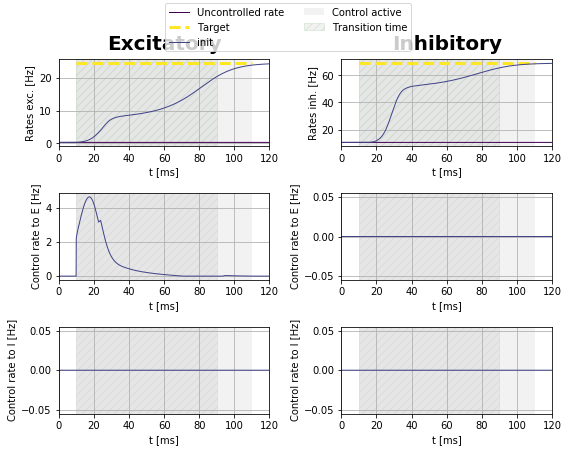

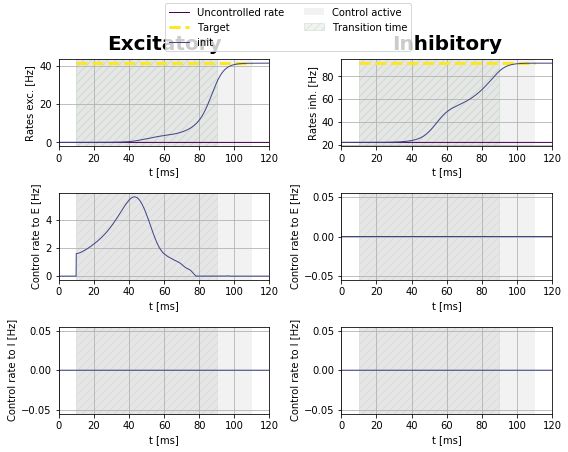

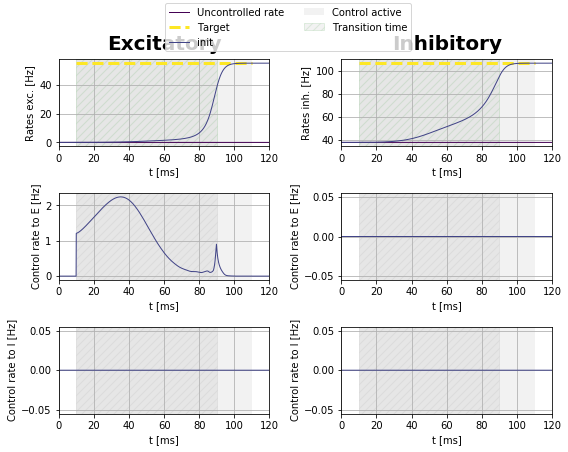

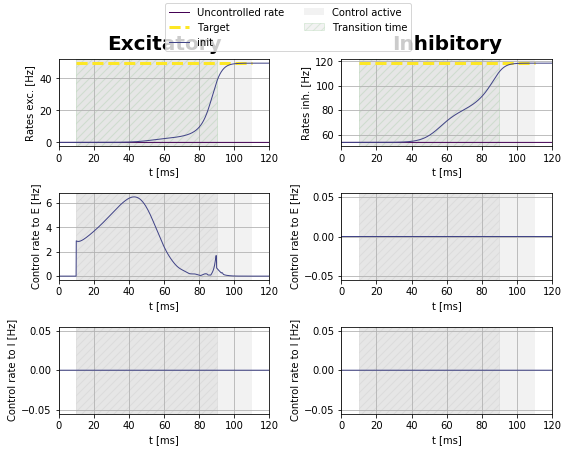

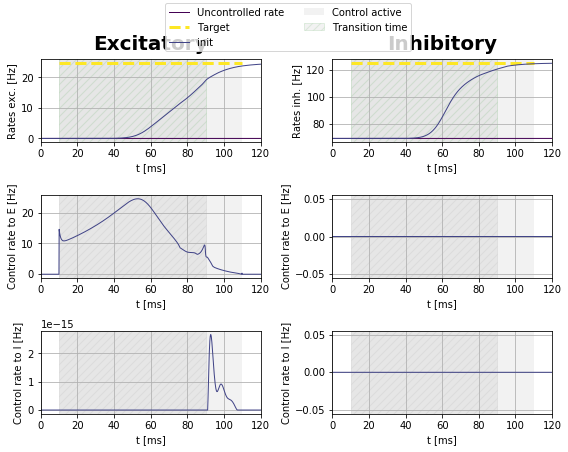

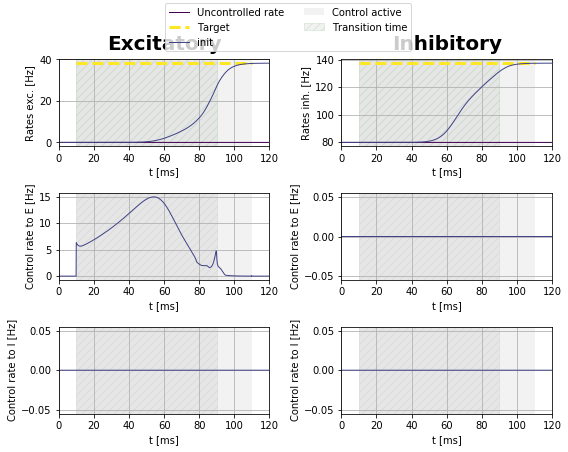

In [155]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_rate(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    
    if i == 104:
        print(costnode_init[i])

In [154]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [[]] * len(exc)

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
    
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            already_tried[i].append(closest_)
        
        if closest_ == -1:
            print("all options tried already")
            no_solution.append(i)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  26 0.47500000000000014 0.4750000000000002
found solution for  26
-------  52 0.5500000000000003 0.5750000000000003
found solution for  52
-------  78 0.5250000000000001 0.6750000000000004
found solution for  78
-------  104 0.4250000000000001 0.7750000000000005
1.4547635461123178e-11 24.74019029961598 1.4547635461123178e-11 1.4547635461123178e-11
26 []
52 []
78 []
closest index  78
set cost params:  1.0 0.0 10.0
precision vars =  [0]
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6121.1207707468575
Gradient descend method:  None
RUN  1 , total integrated cost =  6120.770160654348
RUN  2 , total integrated cost =  6120.770160604903
RUN  3 , total integrated cost =  6120.770160604903
Control only changes marginally.

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  293 , total integrated cost =  1.580381042351155
Improved over  293  iterations in  19.796209299998736  seconds by  99.97418351975385  percent.
Problem in initial value trasfer:  sigmae_f 1.5023716509308478 1.5023917393984312
Problem in initial value trasfer:  Vmean_exc -56.625492768595635 -56.62552392766399
Problem in initial value trasfer:  tau_exc 2.4743638829649615 2.4743610705795
weight =  38729.71135808455
set cost params:  1.0 0.0 38729.71135808455
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6116.196805524833
Gradient descend method:  None
RUN  1 , total integrated cost =  5887.394329407544
RUN  2 , total integrated cost =  5884.347880091084
RUN  3 , total integrated cost =  5875.137550378156
RUN  4 , total integrated cost =  5872.344027192468
RUN  5 , total integrated cost =  5869.296033901812
RUN  6 , total integrated cost =  5860.97801979144
RUN  7 , total integrated cost =  5859.4569

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  33 , total integrated cost =  5820.172915471878
Improved over  33  iterations in  3.14790510000239  seconds by  4.839999422280741  percent.
Problem in initial value trasfer:  sigmae_f 1.5026903564740977 1.5026990635566644
Problem in initial value trasfer:  Vmean_exc -56.623780982912514 -56.62380575362165
Problem in initial value trasfer:  tau_exc 2.5904072319126743 2.5904053481353073
-------  130 0.47500000000000014 0.8500000000000005
------------------------------------------------------------
-------------------- 2
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
-------  26 0.47500000000000014 0.4750000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  104 0.4250000000000001 0.7750000000000005
24.338441348331823 24.74019029961598 24.338441348331823 1.4547635461123178e-11
found solution for  104
-------  130 0.475000000

In [157]:
factor_iteration = 20
full_converge = False

conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
    
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  373951.57096910314
set cost params:  1.0 0.0 373951.57096910314
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5896.691230135715
Gradient descend method:  None
RUN  1 , total integrated cost =  5896.510383772081
RUN  2 , total integrated cost =  5896.505399755238
RUN  3 , total integrated cost =  5896.505074580345
RUN  4 , total integrated cost =  5896.505035610087
RUN  5 , total integrated cost =  5896.505031552712
RUN  6 , total integrated cost =  5896.505031055838
RUN  7 , total integrated cost =  5896.5050309936505
RUN  8 , total integrated cost =  5896.505030986076
RUN  9 , total integrated cost =  5896.5050309851595
RUN  10 , total integrated cost =  5896.505030985066
RUN  11 , total integrated cost =  5896.5050309850585
RUN  12 , total integrated cost =  5896.

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  13 , total integrated cost =  5896.505030985034
Improved over  13  iterations in  1.3764412000018638  seconds by  0.0031576886666471182  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6072157631181287
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.24320181221602
Problem in initial value trasfer:  Vmean_exc -56.62664662588041 -56.626654171223024
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  641247.0751589603
set cost params:  1.0 0.0 641247.0751589603
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17053.267236093394
Gradient descend method:  None
RUN  1 , total integrated cost =  17052.305901863096
RUN  2 , total integrated cost =  17052.301295505153
RUN  3 , total integrated cost =  17052.30129496956
RUN  4 , total integrated cost =  17052.301294967805
RUN  5 , total integrated cost =  17052.301294967794


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  17052.301294967787
RUN  7 , total integrated cost =  17052.301294967787
Control only changes marginally.
RUN  7 , total integrated cost =  17052.301294967787
Improved over  7  iterations in  0.869245800000499  seconds by  0.005664258421774093  percent.
Problem in initial value trasfer:  sigmae_f 1.5251916446527685 1.5251751291433493
Problem in initial value trasfer:  tau_exc 20.792731639271764 20.79284771902187
Problem in initial value trasfer:  Vmean_exc -56.68742105310868 -56.68742406724753
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  2404454.8454825575
set cost params:  1.0 0.0 2404454.8454825575
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30170.508576375185
Gradient descend method:  None
RUN  1 , total integrated cost =  30169.8499674591
RUN  2 , total integrated cost =  30169.83044980724
RUN  3 , total integrated cost =  30169.82998616219
RUN  4 , total integrated

...

24574.61901478388
Control only changes marginally.
RUN  1 , total integrated cost =  24574.61901478388
Improved over  1  iterations in  0.18543810000119265  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5033533472016083 1.5033522192374587
Problem in initial value trasfer:  tau_exc 21.405157768934426 21.4051642327916
Problem in initial value trasfer:  Vmean_exc -56.70191340328952 -56.70191372538575
-------  104 0.4250000000000001 0.7750000000000005
no convergence
weight =  40761.555642484665
set cost params:  1.0 0.0 40761.555642484665
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.619984824385
Gradient descend method:  None
RUN  1 , total integrated cost =  6120.619984824385


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost =  6120.619984824385
Improved over  1  iterations in  0.1832460000005085  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5027040361954658 1.502712755334419
Problem in initial value trasfer:  Vmean_exc -56.62372327519905 -56.62374850517802
Problem in initial value trasfer:  tau_exc 2.5956219733319443 2.595620028844946
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  165164.38739918207
set cost params:  1.0 0.0 165164.38739918207
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.890918645227
Gradient descend method:  None
RUN  1 , total integrated cost = 

ERROR:root:Problem in initial value trasfer


 14547.890918645227
Control only changes marginally.
RUN  1 , total integrated cost =  14547.890918645227
Improved over  1  iterations in  0.18008180000106222  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.676824952771256 -56.67683651985824
[[False, False], [True, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
[[True, False], [True, True], [True, False], [True, False], [True, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  

In [158]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [159]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [160]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  26  52  78 104 130]


In [161]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  51.46137952192833
Gradient descend method:  None
RUN  1 , total integrated cost =  0.20043815622527375
RUN  2 , total integrated cost =  0.19437571959498318
RUN  3 , total integrated cost =  0.1903016651915828
RUN  4 , total integrated cost =  0.18702888609535787
RUN  5 , total integrated cost =  0.1854596677318281
RUN  6 , total integrated cost =  0.18386992227182727
RUN  7 , total integrated cost =  0.18296722981018898
RUN  8 , total integrated cost =  0.18163810237127043
RUN  9 , total integrated cost =  0.18082741753038395
RUN  10 , total integrated cost =  0.17649279266604756
RUN  11 , total integrated cost =  0.17634030111219248
RUN  12 , total integrated cost =  0.17630828727923703
RUN  13 , total integrated cost =  0.17583077561581395
RUN  14 , total integrated cost =  0.1755034901740234
RUN  15 , tota

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  34 , total integrated cost =  0.1747592941061951
Improved over  34  iterations in  5.704886200001056  seconds by  99.660406899835  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6071768281729715
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.24364572164657
Problem in initial value trasfer:  Vmean_exc -56.62762094909442 -56.62762093146557
weight =  100
set cost params:  1.0 0.0 100.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.7428073851888077
Gradient descend method:  HS
RUN  1 , total integrated cost =  1.7360489770175596
RUN  2 , total integrated cost =  1.7340640392222315
RUN  3 , total integrated cost =  1.7340640392222293
RUN  4 , total integrated cost =  1.734064039222228


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  1.734064039222228
Control only changes marginally.
RUN  5 , total integrated cost =  1.734064039222228
Improved over  5  iterations in  1.0884173000013107  seconds by  0.5016817142780639  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6072180160098521
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.243176126296138
Problem in initial value trasfer:  Vmean_exc -56.627627585374235 -56.627627455024665
weight =  340378.9597785503
set cost params:  1.0 0.0 340378.9597785503
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5866.148237410204
Gradient descend method:  None
RUN  1 , total integrated cost =  5466.68045172657
RUN  2 , total integrated cost =  5463.910771159322
RUN  3 , total integrated cost =  5458.165153790107
RUN  4 , total integrated cost =  5449.871851120893
RUN  5 , total integrated cost =  5448.8133605842795
RUN  6 , total integrated cost =  5350.37

...

Control only changes marginally.
RUN  276 , total integrated cost =  0.9471967990035226
Improved over  276  iterations in  53.22198750000098  seconds by  99.4884878663221  percent.
Problem in initial value trasfer:  Vmean_exc -56.67729533501898 -56.677295417436426
weight =  100
set cost params:  1.0 0.0 100.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.45831340098233
Gradient descend method:  HS
RUN  1 , total integrated cost =  9.431637560061729
RUN  2 , total integrated cost =  9.38969106542411
RUN  3 , total integrated cost =  9.38951024761108
RUN  4 , total integrated cost =  9.384228624483782
RUN  5 , total integrated cost =  9.384228624483777
RUN  6 , total integrated cost =  9.384228624483773


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  9.384228624483773
Control only changes marginally.
RUN  7 , total integrated cost =  9.384228624483773
Improved over  7  iterations in  1.5332560999995621  seconds by  0.7832768206947236  percent.
Problem in initial value trasfer:  Vmean_exc -56.67730173690508 -56.67730161901261
weight =  155024.83777001256
set cost params:  1.0 0.0 155024.83777001256
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14480.523704119978
Gradient descend method:  None
RUN  1 , total integrated cost =  13769.44100211319
RUN  2 , total integrated cost =  13766.593873593602
RUN  3 , total integrated cost =  13765.412907191801
RUN  4 , total integrated cost =  13727.857106505502
RUN  5 , total integrated cost =  13701.515095172312
RUN  6 , total integrated cost =  13701.117179097942
RUN  7 , total integrated cost =  13700.979559769723
RUN  8 , total integrated cost =  13700.564983463732
RUN  9 , total integrated cost =  13663.

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  13644.297547504382
Control only changes marginally.
RUN  17 , total integrated cost =  13644.297547504382
Improved over  17  iterations in  4.0058969000019715  seconds by  5.774833657277696  percent.
Problem in initial value trasfer:  Vmean_exc -56.67694538943803 -56.67695383709161


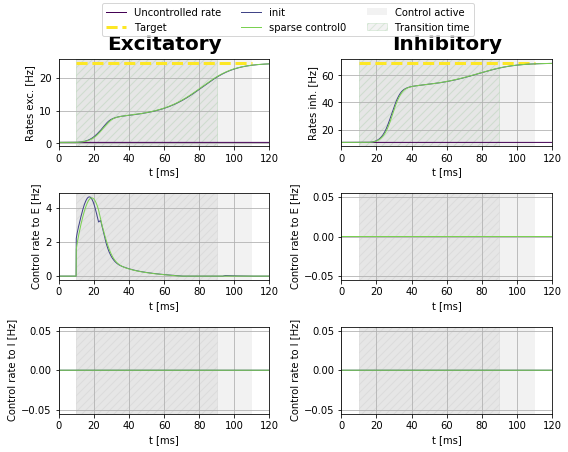

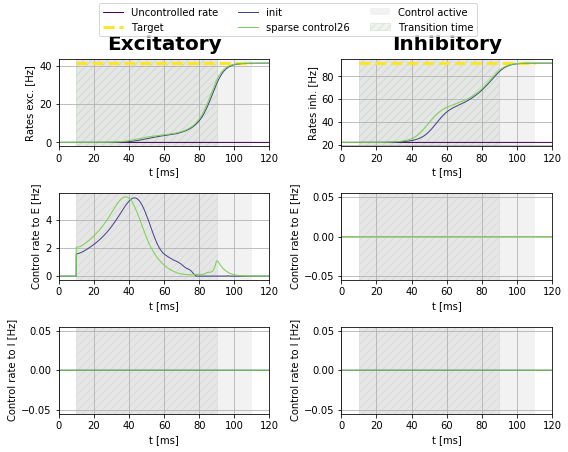

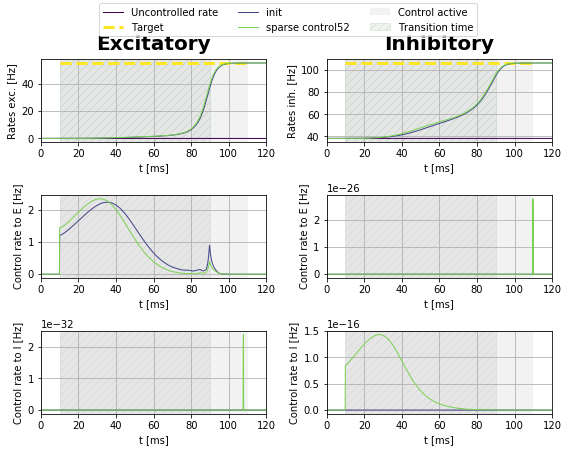

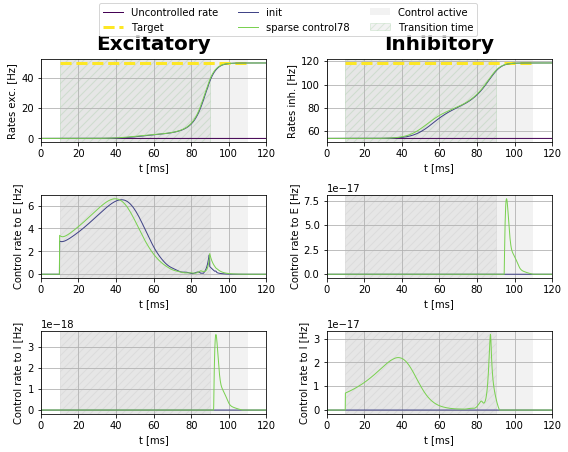

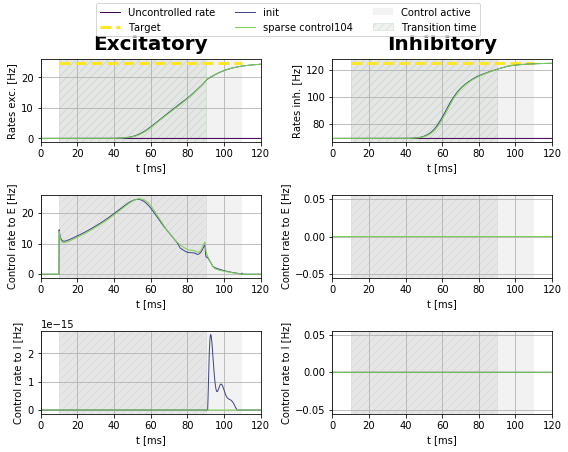

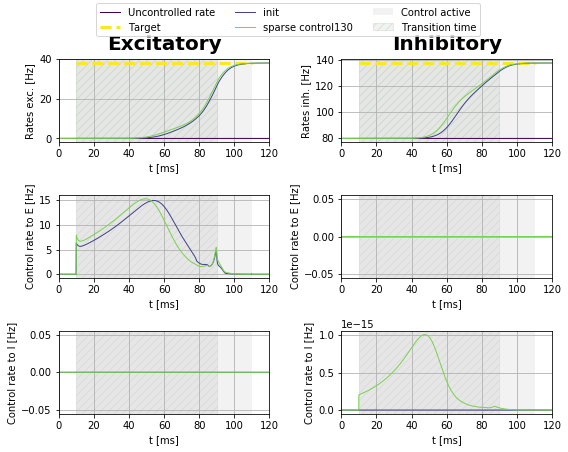

In [162]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_rate(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [163]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    if all(conv == True for conv in conv_0[::i_stepsize][0]):
        if all(conv == True for conv in conv_0[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  375525.57627508015
set cost params:  1.0 0.0 375525.57627508015
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5897.471867962861
Gradient descend method:  None
RUN  1 , total integrated cost =  5897.283720821612
RUN  2 , total integrated cost =  5897.283706362654
RUN  3 , total integrated cost =  5897.283706362647
RUN  4 , total integrated cost =  5897.283706362645


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  5897.283706362645
Control only changes marginally.
RUN  5 , total integrated cost =  5897.283706362645
Improved over  5  iterations in  1.3635247000020172  seconds by  0.0031905468042765506  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6077536926342162
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.237068710340605
Problem in initial value trasfer:  Vmean_exc -56.62664052269033 -56.62664813537904
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  640496.194431563
set cost params:  1.0 0.0 640496.194431563
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17064.518544761006
Gradient descend method:  None
RUN  1 , total integrated cost =  17064.46503595788
RUN  2 , total integrated cost =  17064.462222736536
RUN  3 , total integrated cost =  17064.461762780968
RUN  4 , total integrated cost =  17064.461678148808
RUN  5 , total integrate

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  17064.46166867198
Control only changes marginally.
RUN  14 , total integrated cost =  17064.46166867198
Improved over  14  iterations in  3.2905888999994204  seconds by  0.0003333002854901679  percent.
Problem in initial value trasfer:  sigmae_f 1.5251916446527685 1.5251705844410768
Problem in initial value trasfer:  tau_exc 20.792731639271764 20.792879661597226
Problem in initial value trasfer:  Vmean_exc -56.68744772747118 -56.68744993826205
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  2397696.860174362
set cost params:  1.0 0.0 2397696.860174362
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30180.163361102394
Gradient descend method:  None
RUN  1 , total integrated cost =  30179.94527653516
RUN  2 , total integrated cost =  30179.936372746604
RUN  3 , total integrated cost =  30179.935968332004
RUN  4 , total integrated cost =  30179.935872143844
RUN  5 , total integ

...

RUN  1 , total integrated cost =  30191.221685775356
Control only changes marginally.
RUN  1 , total integrated cost =  30191.221685775356
Improved over  1  iterations in  0.38680250000106753  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5089984866711765 1.5089036530320343
Problem in initial value trasfer:  tau_exc 20.22212870481327 20.222958528313654
Problem in initial value trasfer:  Vmean_exc -56.704396467541436 -56.70439644457773
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
no convergence
weight =  40788.746769288766
set cost params:  1.0 0.0 40788.746769288766
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.620086212537
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6120.620086212537
Control only changes marginally.
RUN  1 , total integrated cost =  6120.620086212537
Improved over  1  iterations in  0.39728110000214656  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5027238333160415 1.5027258734246416
Problem in initial value trasfer:  Vmean_exc -56.62367741501094 -56.623692535035005
Problem in initial value trasfer:  tau_exc 2.6006928722190357 2.600692404023066
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  165385.4725087267
set cost params:  1.0 0.0 165385.4725087267
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.891074091034
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14547.891074091034
Control only changes marginally.
RUN  1 , total integrated cost =  14547.891074091034
Improved over  1  iterations in  0.40085659999749623  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67693085230746 -56.67693965031124
--------------- 4
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
--------------- 5
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.67500000000000

In [164]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [165]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [166]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [167]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)
        
print(i_range_1)

[  0  26  52  78 104 130]


In [168]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  51.64631622256999
Gradient descend method:  None
RUN  1 , total integrated cost =  0.02201002567110202
RUN  2 , total integrated cost =  0.021664788423405468
RUN  3 , total integrated cost =  0.021295640833107376
RUN  4 , total integrated cost =  0.021156249888264703
RUN  5 , total integrated cost =  0.021109636695256215
RUN  6 , total integrated cost =  0.02106124586559579
RUN  7 , total integrated cost =  0.021021082674188077
RUN  8 , total integrated cost =  0.02097097871356679
RUN  9 , total integrated cost =  0.02092333652906123
RUN  10 , total integrated cost =  0.020860150267543297
RUN  11 , total integrated cost =  0.020789378867482878
RUN  12 , total integrated cost =  0.02058441439819356
RUN  13 , total integrated cost =  0.020381826818517006
RUN  14 , total integrated cost =  0.018609533665923182
RUN

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  147 , total integrated cost =  0.017579469952624202
Improved over  147  iterations in  9.896111999998539  seconds by  99.96596181250011  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6076739399650941
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.23797799534902
Problem in initial value trasfer:  Vmean_exc -56.627621333316796 -56.62762131699569
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81.4304763130071
Gradient descend method:  None
RUN  1 , total integrated cost =  0.030790549602597493
RUN  2 , total integrated cost =  0.029943051886814797
RUN  3 , total integrated cost =  0.02948691363434244
RUN  4 , total integrated cost =  0.029261487529688265
RUN  5 , total integrated cost =  0.02909504254584329
RUN  6 , total integrated cost =  0.029015401543517942
RUN  7 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  68 , total integrated cost =  0.028438626243167345
Improved over  68  iterations in  5.997533800000383  seconds by  99.96507618826413  percent.
Problem in initial value trasfer:  sigmae_f 1.5251916446527685 1.5251687165894776
Problem in initial value trasfer:  tau_exc 20.792731639271764 20.792892789847855
-------  52 0.5500000000000003 0.5750000000000003
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  176.21339740520105
Gradient descend method:  None
RUN  1 , total integrated cost =  0.013900327820648034
RUN  2 , total integrated cost =  0.013889735341879716
RUN  3 , total integrated cost =  0.013867839632105514
RUN  4 , total integrated cost =  0.013861745567288032
RUN  5 , total integrated cost =  0.013847386667483497
RUN  6 , total integrated cost =  0.01382792919555962
RUN  7 , total integrated cost =  0.013826147775286898
RUN  8 , total integrated cost =  0.013820

...

RUN  40 , total integrated cost =  0.03728645778688785
Control only changes marginally.
RUN  41 , total integrated cost =  0.03728645778688785
Improved over  41  iterations in  3.3505391999970016  seconds by  99.96036672593969  percent.
Problem in initial value trasfer:  sigmae_f 1.5033533472016083 1.503351979690413
Problem in initial value trasfer:  tau_exc 21.405157768934426 21.405165605528392
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  98.14191490557167
Gradient descend method:  None
RUN  1 , total integrated cost =  0.582304988382209
RUN  2 , total integrated cost =  0.4934388433643811
RUN  3 , total integrated cost =  0.44124601353181336
RUN  4 , total integrated cost =  0.36031964992803733
RUN  5 , total integrated cost =  0.31047450228898865
RUN  6 , total integrated cost =  0.22597225327913195
RUN  7 , total integrated cost =  0.202793929132451

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  259 , total integrated cost =  0.15807369650675795
Improved over  259  iterations in  13.235561500001495  seconds by  99.83893355182762  percent.
Problem in initial value trasfer:  sigmae_f 1.5023925504715152 1.5023941487226238
Problem in initial value trasfer:  Vmean_exc -56.62552141820636 -56.62552389063309
Problem in initial value trasfer:  tau_exc 2.4745410265372567 2.4745408027821014
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  129.15890584925714
Gradient descend method:  None
RUN  1 , total integrated cost =  0.10024784733156807
RUN  2 , total integrated cost =  0.0982643032794464
RUN  3 , total integrated cost =  0.09720068870017948
RUN  4 , total integrated cost =  0.09677852190941008
RUN  5 , total integrated cost =  0.09644227606830146
RUN  6 , total integrated cost =  0.09629938586997877
RUN  7 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  156 , total integrated cost =  0.09438659087036441
Improved over  156  iterations in  10.283680900000036  seconds by  99.92692211950097  percent.
Problem in initial value trasfer:  Vmean_exc -56.677295309121014 -56.67729532047623


In [169]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
    
    print(conv_1[::i_stepsize])
    
    if all(conv == True for conv in conv_1[::i_stepsize][0]):
        if all(conv == True for conv in conv_1[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.017579469952624202
Gradient descend method:  None
RUN  1 , total integrated cost =  0.017579469952624202
Control only changes marginally.
RUN  1 , total integrated cost =  0.017579469952624202
Improved over  1  iterations in  0.1603145000008226  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223344 1.6076739399650941
Problem in initial value trasfer:  tau_exc 17.220111838879994 17.23797799534902
Problem in initial value trasfer:  Vmean_exc -56.627621333316796 -56.62762131699569
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  0.028438626243167345
Gradient descend method:  None
RUN  1 , total integrated cost =  0.028438626243167345
Control only changes marginally.
RUN  1 , total integrated cost =  0.028438626243167345
Improved over  1  iterations in  0.15743039999870234  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5251916446527685 1.5251687165894776
Problem in initial value trasfer:  tau_exc 20.792731639271764 20.792892789847855
-------  52 0.5500000000000003 0.5750000000000003
no convergence
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.013753423439248319
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.013753423439248319
Control only changes marginally.
RUN  1 , total integrated cost =  0.013753423439248319
Improved over  1  iterations in  0.15802909999911208  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5089984866711765 1.5088942881037626
Problem in initial value trasfer:  tau_exc 20.22212870481327 20.223040474315404
-------  78 0.5250000000000001 0.6750000000000004
no convergence
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.03728645778688785
Gradient descend method:  None
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 1 , total integrated cost =  0.03728645778688785
Control only changes marginally.
RUN  1 , total integrated cost =  0.03728645778688785
Improved over  1  iterations in  0.15862579999884474  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5033533472016083 1.503351979690413
Problem in initial value trasfer:  tau_exc 21.405157768934426 21.405165605528392
-------  104 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.15807369650675795
Gradient descend method:  None
RUN  1 , total integrated cost =  0.15807369650675795
Control only changes marginally.
RUN  1 , total integrated cost =  0.15807369650675795
Improved over  1  iterations in  0.15720080000028247  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5023925504715152 1.5023941487226238
Problem in initial value trasfer:  Vmean_exc -56.62552141820636 -56.6255

ERROR:root:Problem in initial value trasfer



set cost params:  1.0 0.0 1.0
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.09438659087036441
Gradient descend method:  None
RUN  1 , total integrated cost =  0.09438659087036441
Control only changes marginally.
RUN  1 , total integrated cost =  0.09438659087036441
Improved over  1  iterations in  0.15129499999966356  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677295309121014 -56.67729532047623
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
[[Tru

In [170]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
